这是Andrej Karpathy的课件 micrograd 的笔记！

1. 先讲基本的微分或者求导的概念

In [35]:
%matplotlib inline
import math
import numpy as np
import matplotlib.pyplot as plt


In [36]:
def f(x):
    return 2*x**2 + 4*x + 1

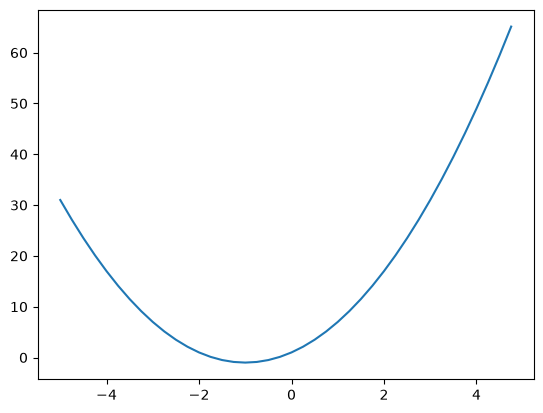

In [37]:
x = np.arange(-5, 5, 0.25)
y = f(x)
plt.plot(x, y)

In [38]:
h = 0.000001
a = 2/3
(f(a + h) - f(a))/h

6.6666686668881425

2. 开始讲设计的 Value 数据结构，类似于 torch 的最低纬度的张量 tensor

In [155]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda:None

    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        self.grad = 1.0
        build_topo(self)
        for node in reversed(topo):
            node._backward()

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def backward():
            self.grad += 1.0 * out.grad
            other.grad +=  1.0 * out.grad
        out._backward = backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = backward
        return out

    def __rmul__(self, other):
        return self * other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def exp(self):
        out = Value(math.exp(self.data), (self,), f'exp()')
        def backward():
            self.grad +=  out.data * out.grad
        out._backward = backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')

        def backward():
            self.grad += out.data * other / self.data * out.grad
        out._backward = backward
        return out

    def __truediv__(self, other):
        return self * (other ** -1)

    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = backward
        return out

3. 开始介绍可视化的包，用于画出 Value 节点的图

In [54]:
from graphviz import Digraph

In [55]:
def trace(root):
    # 建立一个包含节点和边的图结构
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

In [56]:
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR表示从左到右
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # 对图中的任意一个 Value 节点建立一个 'record' 样式的长方形节点图
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            # 如果有运算符，就建立一个运算符节点
            dot.node(name = uid + n._op, label = n._op)
            # 在 Value 节点与运算符节点之间连一条线
            dot.edge(uid +  n._op, uid)

    for n1, n2 in edges:
        # 把 n1 节点与 n2 的运算符节点之间连一条边
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot      

In [57]:
nodes, edges = trace(d)

In [58]:
nodes

{Value(data=-3.0, label=b),
 Value(data=-6.0, label=),
 Value(data=10.0, label=c),
 Value(data=2.0, label=a),
 Value(data=4.0, label=)}

In [59]:
edges

{(Value(data=-3.0, label=b), Value(data=-6.0, label=)),
 (Value(data=-6.0, label=), Value(data=4.0, label=)),
 (Value(data=10.0, label=c), Value(data=4.0, label=)),
 (Value(data=2.0, label=a), Value(data=-6.0, label=))}

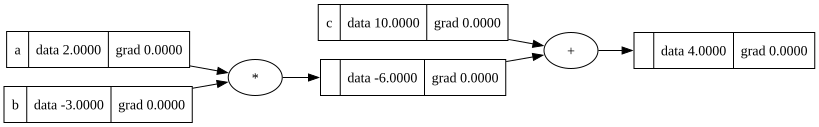

In [60]:
draw_dot(d)

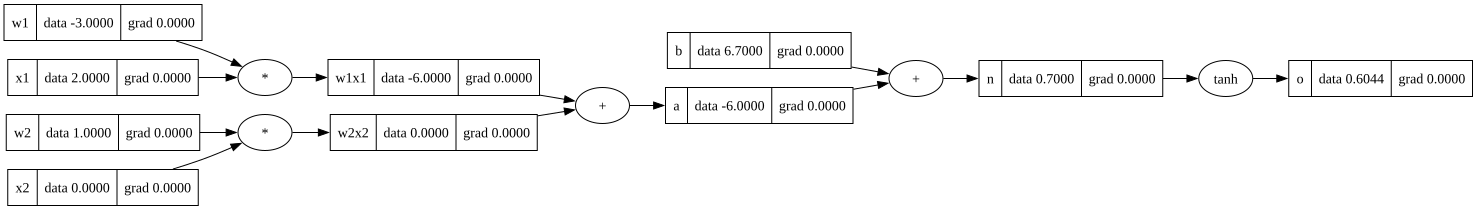

In [136]:
# 输入 x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# 权重 w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# 神经元的偏置 b
b = Value(6.7, label='b')

w1x1 = w1*x1; w1x1.label = 'w1x1'
w2x2 = w2*x2; w2x2.label = 'w2x2'

a = w1x1 + w2x2; a.label = 'a'
n = a + b; n.label = 'n'
out = n.tanh(); out.label = 'o'
draw_dot(out)

4. 介绍反向传播算法

先手动使用算法，然后可视化图像展示数值变化

再写程序。

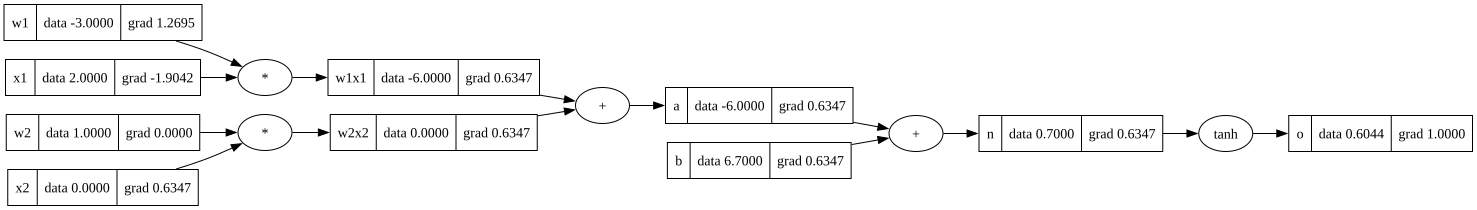

In [110]:
draw_dot(out)

4.1 拓扑排序算法

这个反向传播需要使用拓扑排序算法

In [95]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(out)

In [97]:
topo

[Value(data=1.0, label=w2),
 Value(data=0.0, label=x2),
 Value(data=0.0, label=w2x2),
 Value(data=2.0, label=x1),
 Value(data=-3.0, label=w1),
 Value(data=-6.0, label=w1x1),
 Value(data=-6.0, label=a),
 Value(data=6.7, label=b),
 Value(data=0.7000000000000002, label=n),
 Value(data=0.6043677771171636, label=o)]

In [137]:
out.backward()

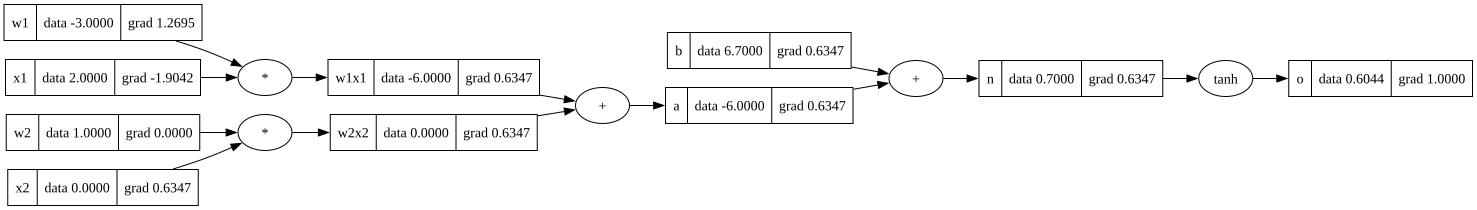

In [138]:
draw_dot(out)

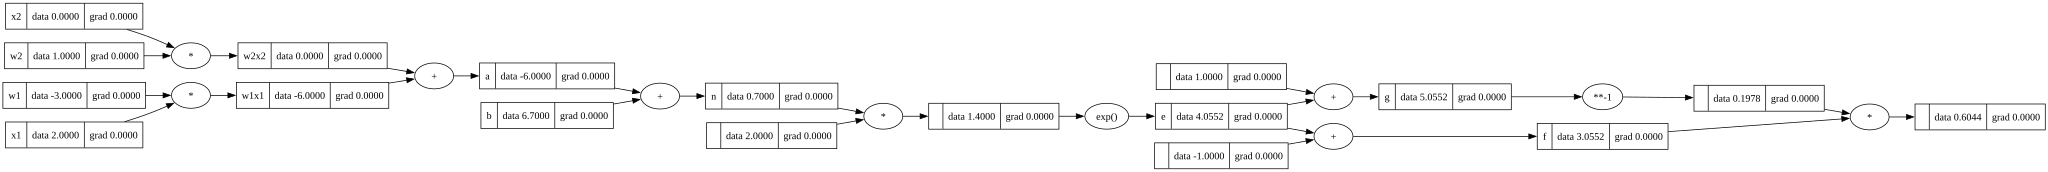

In [156]:
# 测试一下将tanh函数用四则运算和指数函数表示
# 输入 x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# 权重 w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# 神经元的偏置 b
b = Value(6.7, label='b')

w1x1 = w1*x1; w1x1.label = 'w1x1'
w2x2 = w2*x2; w2x2.label = 'w2x2'

a = w1x1 + w2x2; a.label = 'a'
n = a + b; n.label = 'n'

e = (2.0*n).exp(); e.label = 'e'
f = e - 1.0; f.label = 'f'
g = e + 1.0; g.label = 'g'
out2 = f / g; out.label = 'o'
draw_dot(out2)

In [157]:
out2.backward()

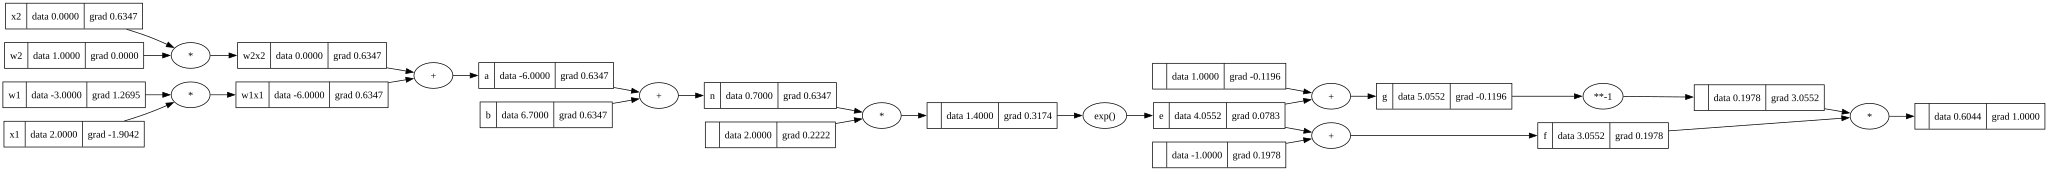

In [158]:
draw_dot(out2)

5. 介绍torch包 

In [170]:
import torch

In [172]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.88137]).double(); b.requires_grad = True
n = w1 * x1 + w2 * x2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("---")
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071050214706146
---
x2 0.5000024886110417
w2 0.0
x1 -1.500007465833125
w1 1.0000049772220834


6. 开始讲神经元！

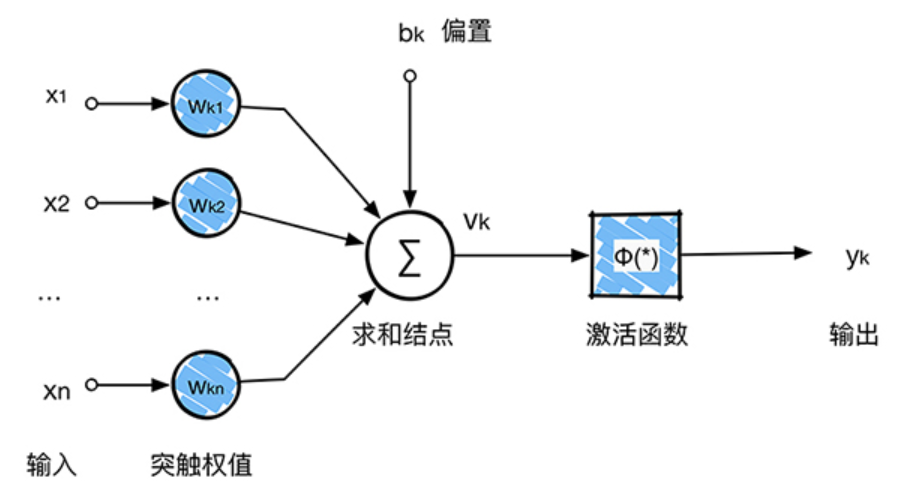

In [182]:
import random

In [202]:
class Neuron:

    def __init__(self, nin):
        # nin 表示这个神经元的输入维度
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # tanh(w * x + b)
        act = sum(wi * xi for wi, xi in zip(self.w, x)) + self.b
        # 上一行也可以写为 act = sum(wi * xi for wi, xi in zip(self.w, x), self.b) 
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

7. 开始讲神经元构成的层
   
    也叫 单层感知机 layer

In [207]:
class Layer:
    def __init__(self, nin, nout):
        # nin表示神经元的输入维度，nout表示这个层有多少个神经元，每个神经元对应一个不同的输出
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

8. 多层感知机

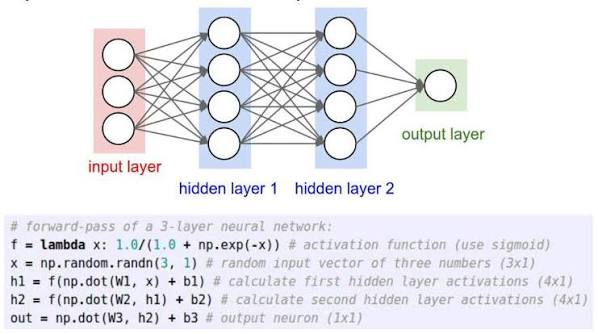

In [208]:
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

看个例子

In [209]:
x = [2., 3., -1.]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.1496724973514837, label=)

In [210]:
len(n.parameters())

41

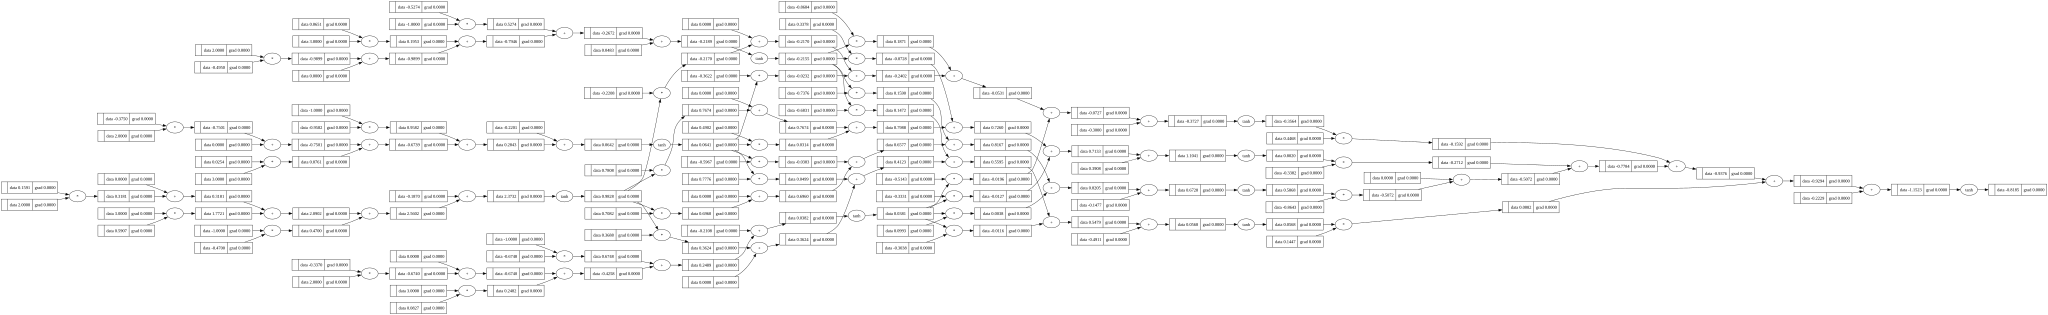

In [188]:
draw_dot(n(x))

9. 看看如何训练MLP

9.1 给定训练数据集
我们要训练一个模型f()，使得给定 x, y 满足 f(x) = y。

In [230]:
# 给定数据集 xs 和对应的 ys
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

# 现在模型根据输入 x 得到的输出值 ypred
ypred = [n(x) for x in xs]
ypred

[Value(data=0.9998723249393558, label=),
 Value(data=-0.9998130330763132, label=),
 Value(data=-0.9998125269404021, label=),
 Value(data=0.9999680911760778, label=)]

9.2 构建损失函数 loss function

In [228]:
# 使用预测值与目标值的差的平方和作为损失函数
# loss 越小，说明预测的越准
loss = sum([(yout - ytg)**2 for ytg, yout in zip(ys, ypred)])
loss

Value(data=0.013501763574873994, label=)

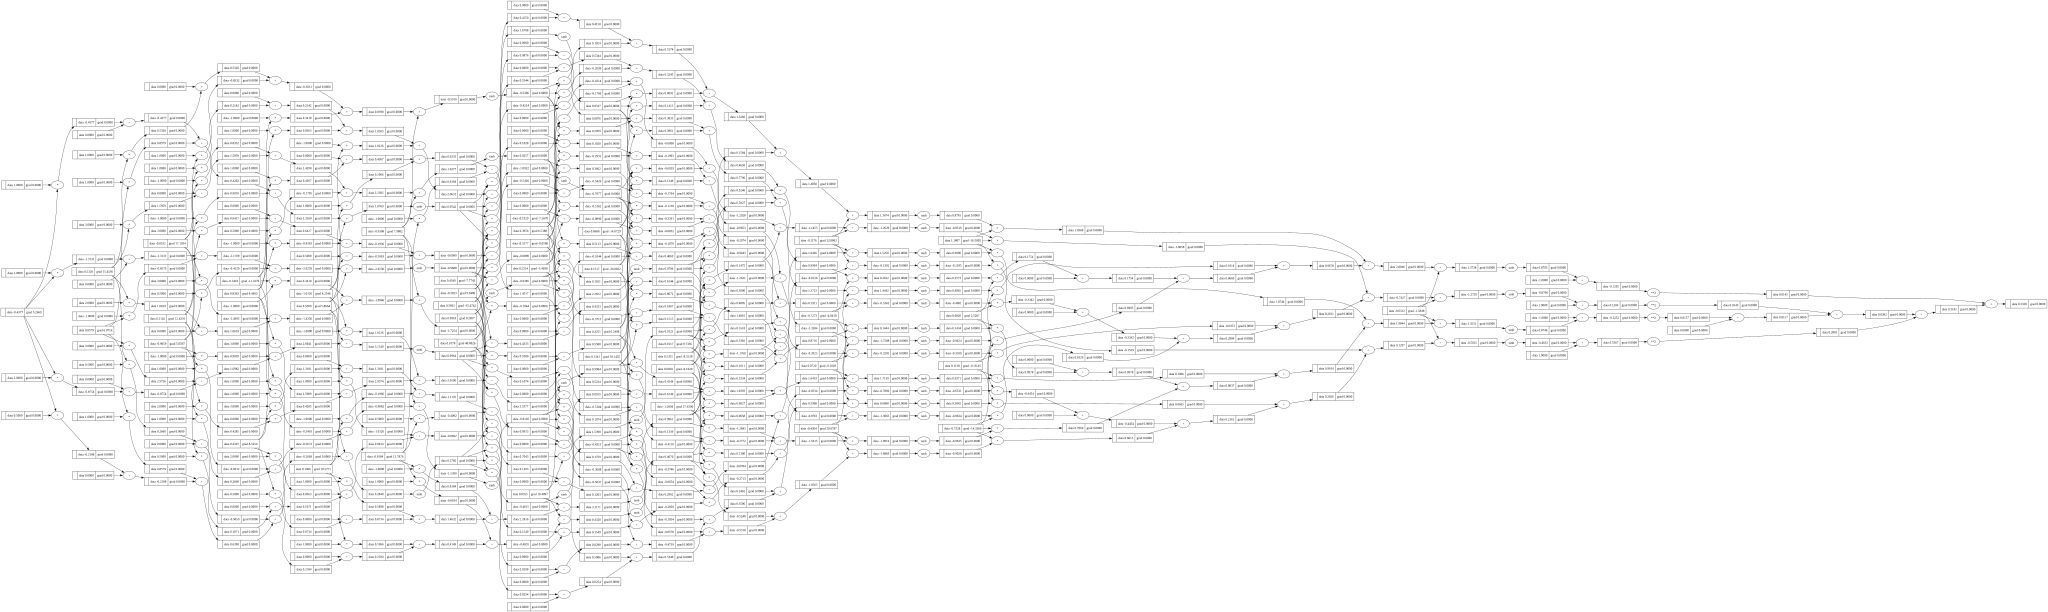

In [223]:
draw_dot(loss)

9.3 使用反向传播算法训练模型

In [224]:
loss.backward()

In [225]:
n.layers[0].neurons[0].w[0].grad

5.547267792349044

In [226]:
for p in n.parameters():
    p.data += -0.01 * p.grad

9.4 训练方式具体如下

forward pass: 使用模型预测输出，并更具预测输出与目标值计算损失函数值

backward pass: 使用反向传播函数计算每个参数的梯度值

update: 利用学习公式更新参数值，降低损失函数值

In [231]:
#epoch表示迭代轮次
epoch = 20

for k in range(epoch):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ytg)**2 for ytg, yout in zip(ys, ypred))

    # backward pass
    # 很重要，因为实现backward是使用累加方式，所以再计算新的grad前需要先归零！！！
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.01 * p.grad

    print(k, loss.data)

0 8.742187278248348e-08
1 8.742184454079798e-08
2 8.74218162992425e-08
3 8.74217880576164e-08
4 8.74217598159187e-08
5 8.742173157438623e-08
6 8.742170333272744e-08
7 8.742167509128901e-08
8 8.742164684968244e-08
9 8.742161860822635e-08
10 8.742159036667209e-08
11 8.742156212524784e-08
12 8.742153388384931e-08
13 8.742150564239423e-08
14 8.74214774010346e-08
15 8.74214491596036e-08
16 8.74214209182964e-08
17 8.742139267707038e-08
18 8.742136443573845e-08
19 8.74213361944888e-08


10. 总结

先直观描述如何计算梯度，接着引入我们自己设计的value数据结构，然后介绍可视化的包，然后介绍backward算法，然后基于value实现神经网络MLP，然后通过一个简单例子说明如何训练一个MLP模型。

10.1 Value数据结构

In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda:None

    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        self.grad = 1.0
        build_topo(self)
        for node in reversed(topo):
            node._backward()

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def backward():
            self.grad += 1.0 * out.grad
            other.grad +=  1.0 * out.grad
        out._backward = backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = backward
        return out

    def __rmul__(self, other):
        return self * other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def exp(self):
        out = Value(math.exp(self.data), (self,), f'exp()')
        def backward():
            self.grad +=  out.data * out.grad
        out._backward = backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')

        def backward():
            self.grad += out.data * other / self.data * out.grad
        out._backward = backward
        return out

    def __truediv__(self, other):
        return self * (other ** -1)

    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = backward
        return out

10.2 MLP数据结构

In [232]:
class Neuron:

    def __init__(self, nin):
        # nin 表示这个神经元的输入维度
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # tanh(w * x + b)
        act = sum(wi * xi for wi, xi in zip(self.w, x)) + self.b
        # 上一行也可以写为 act = sum(wi * xi for wi, xi in zip(self.w, x), self.b) 
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        # nin表示神经元的输入维度，nout表示这个层有多少个神经元，每个神经元对应一个不同的输出
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

10.3 训练MLP模型

首先是有数据集，输入和对应输出(目标值)

构建MLP，确定几层，每层几个神经元

然后确定 损失函数 loss

最后迭代训练

我们拿前面那个例子来举例

In [233]:
# 给定数据集 xs 和对应的 ys，训练MLP n()，使得 n(x) = y
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

In [234]:
# 构建一个输入维度为3，4-4-1的神经网络
n = MLP(3, [4, 4, 1])

In [235]:
# 确定损失函数 loss，这里是使用误差平方和
loss = sum([(yout - ytg)**2 for ytg, yout in zip(ys, ypred)])

In [238]:
# 迭代训练MLP
#epoch表示迭代轮次
epoch = 20
for k in range(epoch):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ytg)**2 for ytg, yout in zip(ys, ypred))

    # backward pass
    # 很重要，因为实现backward是使用累加方式，所以再计算新的grad前需要先归零！！！
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.01 * p.grad

    print(k, loss.data)

0 0.06498381055544342
1 0.06318008141493324
2 0.06147118599575168
3 0.05984994987772374
4 0.05830989624735998
5 0.056845163914527055
6 0.05545043653285381
7 0.054120881289922
8 0.05285209563142017
9 0.051640060825441314
10 0.05048110137042488
11 0.049371849411818214
12 0.048309213465367006
13 0.047290350854596666
14 0.04631264336089317
15 0.045373675660138474
16 0.04447121618289981
17 0.04360320008795739
18 0.04276771408330164
19 0.04196298286610104
